# PART 5

Haikal Ali_1103223071_TK46GAB

# Chapter 5 — Matrices, Part 1


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

## 1. Membuat dan Memvisualisasikan Matrix di NumPy

Matrix dapat dipahami sebagai kumpulan column vector, kumpulan row vector, atau susunan elemen-elemen angka. Dalam data science, matrix sering dipakai seperti tabel data: baris sebagai observation dan kolom sebagai feature.

Ukuran matrix ditulis dengan format **baris × kolom**. Contohnya, matrix berukuran 3 × 5 berarti memiliki 3 baris dan 5 kolom.

Dalam matematika, indexing dimulai dari 1. Dalam Python, indexing dimulai dari 0. Jadi elemen matematika `a3,4` ditulis di Python sebagai `A[2,3]`.

### Contoh slicing matrix

Contoh dari materi: membuat matrix 6 × 10, lalu mengambil submatrix dari baris 2-4 dan kolom 1-5 secara indeks matematika. Dalam Python, itu menjadi `A[1:4:1, 0:5:1]`.

In [2]:
A = np.arange(60).reshape(6, 10)
sub = A[1:4:1, 0:5:1]

print('Original matrix:')
print(A)
print('\nSubmatrix:')
print(sub)

Original matrix:
[[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]
 [20 21 22 23 24 25 26 27 28 29]
 [30 31 32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47 48 49]
 [50 51 52 53 54 55 56 57 58 59]]

Submatrix:
[[10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]


## 2. Special Matrices

Beberapa kategori matrix sering muncul dalam linear algebra dan memiliki fungsi NumPy khusus.

Jenis matrix yang dibahas:
- **Random numbers matrix**: matrix berisi angka random, biasanya dari distribusi Gaussian.
- **Square matrix**: jumlah baris sama dengan jumlah kolom.
- **Nonsquare / rectangular matrix**: jumlah baris dan kolom berbeda.
- **Diagonal matrix**: elemen nonzero hanya berada pada diagonal utama.
- **Triangular matrix**: elemen nonzero hanya berada di atas atau di bawah diagonal utama.
- **Identity matrix**: matrix diagonal dengan nilai 1 pada diagonal utama.
- **Zeros matrix**: matrix yang seluruh elemennya 0.

In [3]:
Mrows = 4
Ncols = 6
A = np.random.randn(Mrows, Ncols)

print(A)

[[ 1.76405235  0.40015721  0.97873798  2.2408932   1.86755799 -0.97727788]
 [ 0.95008842 -0.15135721 -0.10321885  0.4105985   0.14404357  1.45427351]
 [ 0.76103773  0.12167502  0.44386323  0.33367433  1.49407907 -0.20515826]
 [ 0.3130677  -0.85409574 -2.55298982  0.6536186   0.8644362  -0.74216502]]


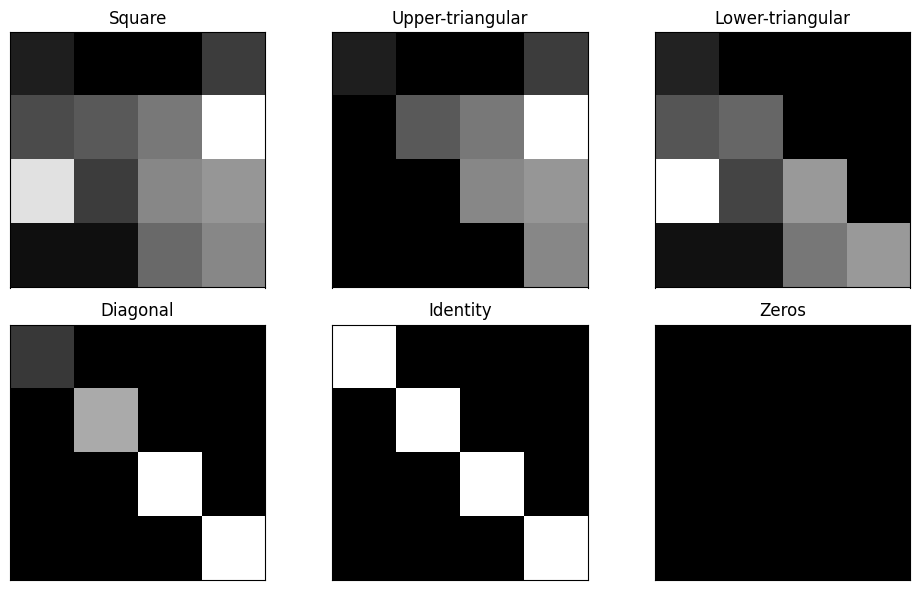

In [4]:
M = np.random.randint(0, 20, (4, 4))

square = M
upper_triangular = np.triu(M)
lower_triangular = np.tril(M)
diagonal = np.diag(np.diag(M))
identity = np.eye(4)
zeros = np.zeros((4, 4))

matrices = [square, upper_triangular, lower_triangular, diagonal, identity, zeros]
titles = ['Square', 'Upper-triangular', 'Lower-triangular', 'Diagonal', 'Identity', 'Zeros']

plt.figure(figsize=(10, 6))
for i, (mat, title) in enumerate(zip(matrices, titles)):
  plt.subplot(2, 3, i+1)
  plt.imshow(mat, cmap='gray')
  plt.title(title)
  plt.xticks([])
  plt.yticks([])
plt.tight_layout()
plt.show()

## 3. Matrix Math: Addition, Scalar Multiplication, dan Hadamard Multiplication

Penjumlahan matrix dilakukan elemen-per-elemen. Dua matrix hanya dapat dijumlahkan jika ukurannya sama.

Scalar-matrix multiplication berarti mengalikan setiap elemen matrix dengan scalar.

Hadamard multiplication berarti mengalikan dua matrix elemen-per-elemen. Di NumPy, operasi ini bisa dilakukan dengan `A*B` atau `np.multiply(A, B)`.

### Shifting matrix

Menambahkan scalar langsung ke matrix, seperti `A + s`, bukan operasi formal linear algebra. Dalam linear algebra, cara menambahkan scalar ke square matrix disebut **shifting**, yaitu menambahkan scalar pada diagonal matrix menggunakan `A + sI`.

In [5]:
A = np.array([[4, 5, 1], [0, 1, 11], [4, 9, 7]])
s = 6

print('A + s, bukan shifting formal:')
print(A + s)

print('\nA + s*np.eye(len(A)), shifting matrix:')
print(A + s*np.eye(len(A)))

A + s, bukan shifting formal:
[[10 11  7]
 [ 6  7 17]
 [10 15 13]]

A + s*np.eye(len(A)), shifting matrix:
[[10.  5.  1.]
 [ 0.  7. 11.]
 [ 4.  9. 13.]]


In [6]:
A = np.random.randn(3, 4)
B = np.random.randn(3, 4)

print('Hadamard multiplication dengan *:')
print(A * B)

print('\nHadamard multiplication dengan np.multiply:')
print(np.multiply(A, B))

# A @ B tidak valid di sini karena ukuran A adalah 3x4 dan B adalah 3x4.
# Untuk matrix multiplication, dimensi bagian dalam harus sama.

Hadamard multiplication dengan *:
[[-0.05006957 -0.51984783  0.68856403 -1.21799284]
 [-0.73399968  1.63130362 -0.31993029 -0.08578212]
 [-0.27834185  0.00176407 -0.47124059 -0.05424324]]

Hadamard multiplication dengan np.multiply:
[[-0.05006957 -0.51984783  0.68856403 -1.21799284]
 [-0.73399968  1.63130362 -0.31993029 -0.08578212]
 [-0.27834185  0.00176407 -0.47124059 -0.05424324]]


## 4. Standard Matrix Multiplication

Matrix multiplication bukan operasi elemen-per-elemen. Operasi ini dilakukan dengan dot product antara baris matrix kiri dan kolom matrix kanan.

Aturan validitas matrix multiplication:


a matrix berukuran **M × N** dapat dikalikan dengan matrix berukuran **N × K**, dan hasilnya berukuran **M × K**.

Bagian dalam harus sama. Bagian luar menentukan ukuran hasil.

Matrix multiplication umumnya **tidak komutatif**. Artinya, `AB` belum tentu sama dengan `BA`, bahkan salah satunya bisa valid sementara yang lain tidak valid.

In [7]:
A = np.array([[2, 3], [4, 5]])
B = np.array([[1, 2], [3, 4]])

print('A @ B:')
print(A @ B)

print('\nB @ A:')
print(B @ A)

A @ B:
[[11 16]
 [19 28]]

B @ A:
[[10 13]
 [22 29]]


## 5. Matrix-Vector Multiplication

Matrix-vector multiplication adalah kasus khusus dari matrix multiplication. Matrix dapat dikalikan dengan column vector dari kanan, atau dikalikan dengan row vector dari kiri, selama ukurannya valid.

Salah satu interpretasinya adalah linear weighted combination: elemen vector menjadi bobot untuk menggabungkan column vectors dalam matrix.

Interpretasi lain adalah geometric transform: matrix dapat memutar dan meregangkan vector.

In [8]:
M = np.array([[2, 3], [2, 1]])
x = np.array([[1, 1.5]]).T
Mx = M @ x

v = np.array([[1.5, 1]]).T
Mv = M @ v

print('x:')
print(x)
print('\nM @ x:')
print(Mx)

print('\nv:')
print(v)
print('\nM @ v:')
print(Mv)

x:
[[1. ]
 [1.5]]

M @ x:
[[6.5]
 [3.5]]

v:
[[1.5]
 [1. ]]

M @ v:
[[6.]
 [4.]]


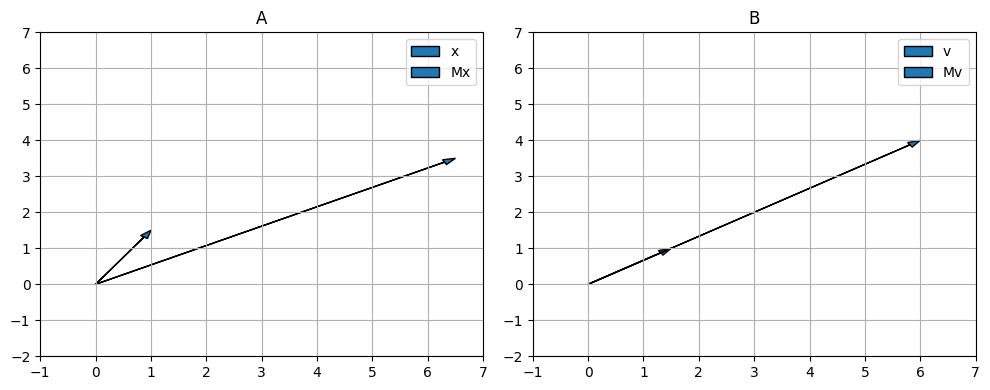

In [9]:
def plot_vector(vec, label):
  plt.arrow(0, 0, vec[0, 0], vec[1, 0], head_width=.15, length_includes_head=True, label=label)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plot_vector(x, 'x')
plot_vector(Mx, 'Mx')
plt.xlim(-1, 7)
plt.ylim(-2, 7)
plt.grid(True)
plt.title('A')
plt.legend()

plt.subplot(1, 2, 2)
plot_vector(v, 'v')
plot_vector(Mv, 'Mv')
plt.xlim(-1, 7)
plt.ylim(-2, 7)
plt.grid(True)
plt.title('B')
plt.legend()

plt.tight_layout()
plt.show()

## 6. Matrix Operations: Transpose

Transpose berarti menukar baris dan kolom. Jika matrix `A` ditranspose, maka hasilnya ditulis `A.T` atau `np.transpose(A)`.

Double transpose mengembalikan matrix ke bentuk awal: `A.T.T = A`.

In [10]:
A = np.array([[3, 4, 5], [1, 2, 3]])
A_T1 = A.T
A_T2 = np.transpose(A)

print('A:')
print(A)
print('\nA.T:')
print(A_T1)
print('\nnp.transpose(A):')
print(A_T2)

A:
[[3 4 5]
 [1 2 3]]

A.T:
[[3 1]
 [4 2]
 [5 3]]

np.transpose(A):
[[3 1]
 [4 2]
 [5 3]]


## 7. Dot Product dan Outer Product Notation

Dot product antara dua column vector ditulis `a.T @ b`, karena `a.T` berukuran 1 × M dan `b` berukuran M × 1. Hasilnya adalah scalar.

Outer product ditulis `a @ b.T`, karena `a` berukuran M × 1 dan `b.T` berukuran 1 × N. Hasilnya adalah matrix M × N.

In [11]:
a = np.array([[1, 2, 3]]).T
b = np.array([[4, 5, 6]]).T

print('Dot product a.T @ b:')
print(a.T @ b)

print('\nOuter product a @ b.T:')
print(a @ b.T)

Dot product a.T @ b:
[[32]]

Outer product a @ b.T:
[[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]


## 8. LIVE EVIL Rule

Aturan LIVE EVIL menjelaskan bahwa transpose dari hasil perkalian beberapa matrix sama dengan perkalian transpose masing-masing matrix, tetapi urutannya dibalik.

Secara umum:

\[
(LIVE)^T = E^T V^T I^T L^T
\]

Urutan dibalik karena matrix multiplication bergantung pada sisi dan urutan.

## 9. Symmetric Matrices

Matrix symmetric adalah matrix yang sama dengan transpose-nya:

\[
A^T = A
\]

Matrix symmetric harus square. Matrix nonsquare tidak bisa symmetric karena ukuran matrix berubah ketika ditranspose.

Salah satu cara membuat symmetric matrix adalah menggunakan multiplicative method:

\[
A^T A
\]

atau

\[
AA^T
\]

Keduanya menghasilkan matrix square symmetric, tetapi ukurannya bisa berbeda jika `A` nonsquare.

In [12]:
A = np.random.randn(3, 5)
AtA = A.T @ A
AAt = A @ A.T

print('A.T @ A shape:', AtA.shape)
print('A @ A.T shape:', AAt.shape)
print('\nApakah A.T @ A symmetric?', np.allclose(AtA, AtA.T))
print('Apakah A @ A.T symmetric?', np.allclose(AAt, AAt.T))

A.T @ A shape: (5, 5)
A @ A.T shape: (3, 3)

Apakah A.T @ A symmetric? True
Apakah A @ A.T symmetric? True


## 10. Summary

Inti materi Chapter 5:
- Matrix adalah susunan angka yang dapat dilihat sebagai row vectors, column vectors, atau elemen individual.
- Beberapa operasi matrix bekerja elemen-per-elemen, seperti addition, scalar multiplication, dan Hadamard multiplication.
- Shifting matrix berarti menambahkan scalar ke diagonal matrix.
- Matrix multiplication adalah kumpulan dot product antara baris matrix kiri dan kolom matrix kanan.
- Aturan validitas matrix multiplication: **M × N dikali N × K menghasilkan M × K**.
- LIVE EVIL: transpose dari perkalian matrix membalik urutan perkalian.
- Symmetric matrix memenuhi `A.T = A`.
- Matrix symmetric dapat dibuat dari `A.T @ A` atau `A @ A.T`.

# Code Exercises

## Exercise 5-1

Buat matrix 3 × 4 menggunakan `np.arange(12).reshape(3,4)`. Lalu ambil elemen pada baris kedua dan kolom keempat. Gunakan softcoding agar indeks baris/kolom bisa diganti.

In [13]:
A = np.arange(12).reshape(3, 4)

row_index_math = 2
col_index_math = 4

row_index_python = row_index_math - 1
col_index_python = col_index_math - 1

element = A[row_index_python, col_index_python]

print(A)
print(f'The matrix element at index ({row_index_math},{col_index_math}) is {element}.')

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
The matrix element at index (2,4) is 7.


## Exercise 5-2

Buat matrix `C` seperti Figure 5-6, lalu gunakan slicing untuk mengambil submatrix berisi lima baris pertama dan lima kolom pertama.

C1:
[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]
 [40 41 42 43 44]]


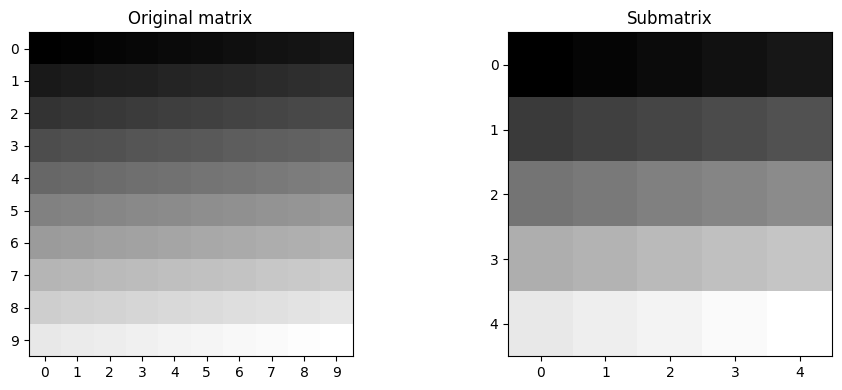

In [14]:
C = np.arange(100).reshape(10, 10)
C1 = C[:5, :5]

print('C1:')
print(C1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(C, cmap='gray')
plt.title('Original matrix')
plt.xticks(range(10))
plt.yticks(range(10))

plt.subplot(1, 2, 2)
plt.imshow(C1, cmap='gray')
plt.title('Submatrix')
plt.xticks(range(5))
plt.yticks(range(5))

plt.tight_layout()
plt.show()

## Exercise 5-3

Ambil empat block 5 × 5 dari matrix `C`, lalu susun ulang block tersebut seperti Figure 5-7.

[[55 56 57 58 59 50 51 52 53 54]
 [65 66 67 68 69 60 61 62 63 64]
 [75 76 77 78 79 70 71 72 73 74]
 [85 86 87 88 89 80 81 82 83 84]
 [95 96 97 98 99 90 91 92 93 94]
 [ 5  6  7  8  9  0  1  2  3  4]
 [15 16 17 18 19 10 11 12 13 14]
 [25 26 27 28 29 20 21 22 23 24]
 [35 36 37 38 39 30 31 32 33 34]
 [45 46 47 48 49 40 41 42 43 44]]


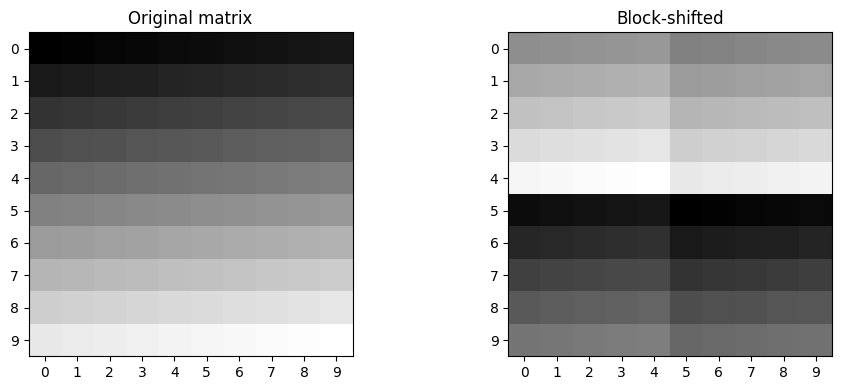

In [15]:
C = np.arange(100).reshape(10, 10)

top_left = C[:5, :5]
top_right = C[:5, 5:]
bottom_left = C[5:, :5]
bottom_right = C[5:, 5:]

block_shifted = np.block([
  [bottom_right, bottom_left],
  [top_right, top_left]
])

print(block_shifted)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(C, cmap='gray')
plt.title('Original matrix')
plt.xticks(range(10))
plt.yticks(range(10))

plt.subplot(1, 2, 2)
plt.imshow(block_shifted, cmap='gray')
plt.title('Block-shifted')
plt.xticks(range(10))
plt.yticks(range(10))

plt.tight_layout()
plt.show()

## Exercise 5-4

Implementasikan matrix addition secara element-wise menggunakan dua for loop. Lalu cek apa yang terjadi jika ukuran matrix tidak cocok.

In [16]:
def matrix_addition_loop(A, B):
  if A.shape != B.shape:
    raise ValueError('Ukuran matrix harus sama untuk penjumlahan matrix.')

  C = np.zeros(A.shape)
  for rowi in range(A.shape[0]):
    for coli in range(A.shape[1]):
      C[rowi, coli] = A[rowi, coli] + B[rowi, coli]

  return C

A = np.random.randn(3, 4)
B = np.random.randn(3, 4)
C_loop = matrix_addition_loop(A, B)
C_numpy = A + B

print('Hasil loop sama dengan NumPy:', np.allclose(C_loop, C_numpy))

D = np.random.randn(4, 4)
try:
  matrix_addition_loop(A, D)
except ValueError as error:
  print('Error ketika ukuran tidak cocok:', error)

Hasil loop sama dengan NumPy: True
Error ketika ukuran tidak cocok: Ukuran matrix harus sama untuk penjumlahan matrix.


## Exercise 5-5

Tunjukkan lewat kode bahwa matrix addition dan scalar multiplication mengikuti commutivity dan distributivity:

\[
\sigma(A+B) = \sigma A + \sigma B = A\sigma + B\sigma
\]

In [17]:
A = np.random.randn(3, 4)
B = np.random.randn(3, 4)
sigma = np.random.randn()

res1 = sigma * (A + B)
res2 = sigma * A + sigma * B
res3 = A * sigma + B * sigma

print('sigma*(A+B) sama dengan sigma*A + sigma*B:', np.allclose(res1, res2))
print('sigma*(A+B) sama dengan A*sigma + B*sigma:', np.allclose(res1, res3))
print('Selisih maksimum res1-res2:', np.max(np.abs(res1-res2)))
print('Selisih maksimum res1-res3:', np.max(np.abs(res1-res3)))

sigma*(A+B) sama dengan sigma*A + sigma*B: True
sigma*(A+B) sama dengan A*sigma + B*sigma: True
Selisih maksimum res1-res2: 8.881784197001252e-16
Selisih maksimum res1-res3: 8.881784197001252e-16


## Exercise 5-6

Buat matrix multiplication menggunakan for loop. Konfirmasi hasilnya dengan operator NumPy `@`.

In [18]:
def matrix_multiply_loop(A, B):
  if A.shape[1] != B.shape[0]:
    raise ValueError('Dimensi bagian dalam harus sama.')

  C = np.zeros((A.shape[0], B.shape[1]))

  for rowi in range(A.shape[0]):
    for coli in range(B.shape[1]):
      C[rowi, coli] = np.sum(A[rowi, :] * B[:, coli])

  return C

A = np.random.randn(3, 4)
B = np.random.randn(4, 5)

C_loop = matrix_multiply_loop(A, B)
C_numpy = A @ B

print('Hasil loop sama dengan NumPy @:', np.allclose(C_loop, C_numpy))
print('Shape hasil:', C_loop.shape)

Hasil loop sama dengan NumPy @: True
Shape hasil: (3, 5)


## Exercise 5-7

Konfirmasi aturan LIVE EVIL:
1. Buat matrix `L`, `I`, `V`, dan `E` dengan ukuran yang diminta.
2. Kalikan semuanya lalu transpose hasilnya.
3. Transpose masing-masing matrix dan kalikan tanpa membalik urutan.
4. Transpose masing-masing matrix dan kalikan dengan urutan dibalik.
5. Ulangi dengan matrix square.

In [19]:
L = np.random.randn(2, 6)
I = np.random.randn(6, 3)
V = np.random.randn(3, 5)
E = np.random.randn(5, 2)

step2 = (L @ I @ V @ E).T

try:
  step3 = L.T @ I.T @ V.T @ E.T
  print('Step 3 valid:', np.allclose(step2, step3))
except ValueError as error:
  print('Step 3 error karena ukuran matrix tidak valid:', error)

step4 = E.T @ V.T @ I.T @ L.T
print('Step 4 sesuai LIVE EVIL:', np.allclose(step2, step4))

Step 3 error karena ukuran matrix tidak valid: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)
Step 4 sesuai LIVE EVIL: True


In [20]:
L = np.random.randn(3, 3)
I = np.random.randn(3, 3)
V = np.random.randn(3, 3)
E = np.random.randn(3, 3)

step2 = (L @ I @ V @ E).T
step3 = L.T @ I.T @ V.T @ E.T
step4 = E.T @ V.T @ I.T @ L.T

print('Square matrix, step 3 tanpa membalik urutan sama?', np.allclose(step2, step3))
print('Square matrix, step 4 LIVE EVIL sama?', np.allclose(step2, step4))
print('Selisih maksimum step2-step3:', np.max(np.abs(step2-step3)))
print('Selisih maksimum step2-step4:', np.max(np.abs(step2-step4)))

Square matrix, step 3 tanpa membalik urutan sama? False
Square matrix, step 4 LIVE EVIL sama? True
Selisih maksimum step2-step3: 19.458669690029662
Selisih maksimum step2-step4: 1.7763568394002505e-15


## Exercise 5-8

Buat fungsi Python untuk mengecek apakah sebuah matrix symmetric. Fungsi menghasilkan `True` jika symmetric dan `False` jika tidak.

In [21]:
def is_symmetric(A, tol=1e-10):
  if A.shape[0] != A.shape[1]:
    return False
  return np.allclose(A, A.T, atol=tol)

A = np.random.randn(4, 4)
symmetric_matrix = A.T @ A
nonsymmetric_matrix = np.random.randn(4, 4)
nonsquare_matrix = np.random.randn(3, 4)

print('symmetric_matrix:', is_symmetric(symmetric_matrix))
print('nonsymmetric_matrix:', is_symmetric(nonsymmetric_matrix))
print('nonsquare_matrix:', is_symmetric(nonsquare_matrix))

symmetric_matrix: True
nonsymmetric_matrix: False
nonsquare_matrix: False


## Exercise 5-9

Buat symmetric matrix dari nonsymmetric square matrix dengan additive method, yaitu merata-ratakan matrix dengan transpose-nya.

In [22]:
A = np.random.randn(4, 4)
A_symmetric = (A + A.T) / 2

print('A symmetric?', is_symmetric(A))
print('A_symmetric symmetric?', is_symmetric(A_symmetric))
print(A_symmetric)

A symmetric? False
A_symmetric symmetric? True
[[ 1.08245595 -1.24544527  0.287637    1.82982627]
 [-1.24544527  0.12614029  0.90908516  0.78906573]
 [ 0.287637    0.90908516 -0.47781636  1.90161145]
 [ 1.82982627  0.78906573  1.90161145  0.07754323]]


## Exercise 5-10

Ulangi bagian kedua Exercise 3-3, tetapi gunakan matrix-vector multiplication, bukan vector-scalar multiplication. Artinya, hitung `As`, bukan `σ1v1 + σ2v2`.

In [23]:
v1 = np.array([3, 5, 1])
v2 = np.array([0, 2, 2])
A = np.column_stack((v1, v2))

scalars = np.random.uniform(-4, 4, (100, 2))
points = (A @ scalars.T).T

print('Shape A:', A.shape)
print('Shape scalars:', scalars.shape)
print('Shape points:', points.shape)

try:
  import plotly.graph_objects as go

  fig = go.Figure(data=[go.Scatter3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2],
    mode='markers'
  )])
  fig.update_layout(title='Random points pada subspace di R3')
  fig.show()
except Exception as error:
  print('Plotly tidak bisa ditampilkan, memakai matplotlib 3D.')
  fig = plt.figure(figsize=(7, 5))
  ax = fig.add_subplot(111, projection='3d')
  ax.scatter(points[:, 0], points[:, 1], points[:, 2])
  plt.show()

Shape A: (3, 2)
Shape scalars: (100, 2)
Shape points: (100, 3)


## Exercise 5-11

Eksplorasi sifat diagonal matrix:
- Premultiplying by diagonal matrix menskalakan baris matrix kanan.
- Postmultiplying by diagonal matrix menskalakan kolom matrix kiri.

Lalu premultiply dan postmultiply matrix ones dengan square-root diagonal matrix.

In [24]:
O = np.ones((4, 4))
D = np.diag([1, 4, 9, 16])
D_sqrt = np.sqrt(D)

print('# Pre-multiply by diagonal:')
print(D @ O)

print('\n# Post-multiply by diagonal:')
print(O @ D)

print('\n# Pre- and post-multiply by sqrt-diagonal:')
print(D_sqrt @ O @ D_sqrt)

# Pre-multiply by diagonal:
[[ 1.  1.  1.  1.]
 [ 4.  4.  4.  4.]
 [ 9.  9.  9.  9.]
 [16. 16. 16. 16.]]

# Post-multiply by diagonal:
[[ 1.  4.  9. 16.]
 [ 1.  4.  9. 16.]
 [ 1.  4.  9. 16.]
 [ 1.  4.  9. 16.]]

# Pre- and post-multiply by sqrt-diagonal:
[[ 1.  2.  3.  4.]
 [ 2.  4.  6.  8.]
 [ 3.  6.  9. 12.]
 [ 4.  8. 12. 16.]]


## Exercise 5-12

Tunjukkan bahwa matrix multiplication sama dengan Hadamard multiplication untuk dua diagonal matrices.

In [25]:
D1 = np.diag([1, 2, 3])
D2 = np.diag([4, 5, 6])

matrix_product = D1 @ D2
hadamard_product = D1 * D2

print('D1 @ D2:')
print(matrix_product)

print('\nD1 * D2:')
print(hadamard_product)

print('\nSama?', np.allclose(matrix_product, hadamard_product))

D1 @ D2:
[[ 4  0  0]
 [ 0 10  0]
 [ 0  0 18]]

D1 * D2:
[[ 4  0  0]
 [ 0 10  0]
 [ 0  0 18]]

Sama? True


Karena kedua matrix adalah diagonal, elemen di luar diagonal bernilai 0. Pada matrix multiplication, setiap elemen diagonal hasil hanya berasal dari perkalian elemen diagonal yang bersesuaian. Karena itu hasilnya sama dengan Hadamard multiplication.